# High-Value Donation Opportunity Forecasting

**Project**: BYU IS 455 — Northstar Shelters ML Pipeline  
**Unit of analysis**: supporter-month snapshot  
**Predictive target**: whether the supporter will give at least ₱1,000 in the next 90 days

---

The original exact-amount regression framing was too unstable on holdout data. This revised notebook keeps the business problem centered on donation value, but reframes it as a **high-value opportunity classification** problem, which is more actionable for a small fundraising team.


## 1. Problem Framing

### Business Question

> *"Which supporters are most likely to become high-value giving opportunities in the next 90 days, so fundraising staff can focus limited high-touch outreach where it matters most?"*

### Who Cares and Why It Matters

- **Fundraising staff** need a shortlist for personal asks, follow-up meetings, and stewardship.
- **Leadership** cares because large gifts can materially change safehouse funding capacity.
- **Program planners** benefit when expected giving is easier to forecast and align to upcoming need.

### Predictive vs. Explanatory Choice

The **primary deployed use is predictive** because the organization needs a ranked list of donors to cultivate now. Following the textbook framework, prediction is the right lens because the business action is future-facing. We still include an explanatory model because the team needs interpretable evidence about which donor patterns are associated with larger future gifts.

- **Predictive track:** identify who should receive scarce high-touch cultivation.
- **Explanatory track:** identify which donor-history signals are associated with higher future giving opportunities.

We frame this as a classification problem around a meaningful threshold rather than exact amount prediction because the operational decision is "who should we prioritize," not "what exact amount will arrive?".


## 2. Data Acquisition, Preparation & Exploration

We reuse the donor-month snapshot framework from the retention pipeline and draw from:

- `supporters.csv`
- `donations.csv`
- `donation_allocations.csv`

### Reproducible Pipeline Setup

This notebook relies on the shared loaders in `IS455/455-Things/ml-pipelines/shared/`, which means the data paths and feature-building logic are centralized and reproducible. A TA should be able to run the notebook from the repository without editing file locations.

### Join Logic

- `supporters` defines the donor entity and static profile fields.
- `donations` contributes dated giving behavior up to each snapshot.
- `donation_allocations` is joined through `donation_id` to capture program breadth and allocation spread.

### Predictive Label

We define a **high-value opportunity** as:

`next_90d_monetary_total >= 1000 PHP`

That threshold is operationally easier to explain than exact donation regression and turns the model into a cultivation-ranking tool.

### Exploration and Preparation

The EDA checks:

- class balance after thresholding future giving
- skew and outliers in past donation amounts
- whether recurring donors differ from one-time donors
- missingness in donor attributes and acquisition-channel fields
- how campaign/channel breadth relates to future giving opportunity

### Leakage Rule

For every supporter-month snapshot:

- features use only history on or before the snapshot date
- the label checks the next 90 days only

That keeps the workflow faithful to the real scoring moment.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import TimeSeriesSplit, cross_validate

from shared.config import DATA_DIR, RANDOM_SEED
from shared.model_utils import save_model, save_predictions

np.random.seed(RANDOM_SEED)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (12, 5)

supporters = pd.read_csv(DATA_DIR / 'supporters.csv', parse_dates=['created_at', 'first_donation_date'])
donations = pd.read_csv(DATA_DIR / 'donations.csv', parse_dates=['donation_date'])
allocations = pd.read_csv(DATA_DIR / 'donation_allocations.csv', parse_dates=['allocation_date'])


In [2]:
min_month = donations['donation_date'].min().to_period('M').to_timestamp()
max_month = (donations['donation_date'].max() - pd.Timedelta(days=90)).to_period('M').to_timestamp()
snapshot_months = pd.date_range(min_month, max_month, freq='MS')

HIGH_VALUE_THRESHOLD = 1000.0
rows = []
for snap in snapshot_months:
    hist = donations[donations['donation_date'] <= snap].copy()
    future = donations[(donations['donation_date'] > snap) & (donations['donation_date'] <= snap + pd.Timedelta(days=90))].copy()
    future_mon = future[future['amount'].notna()].copy()
    future_total = future_mon.groupby('supporter_id')['amount'].sum().reset_index(name='target_next_90d_amount')

    hist_sorted = hist.sort_values(['supporter_id', 'donation_date'])
    base_rows = supporters[['supporter_id', 'supporter_type', 'relationship_type', 'region', 'status', 'acquisition_channel', 'created_at']].copy()

    agg = (
        hist_sorted.groupby('supporter_id')
        .agg(
            last_donation_date=('donation_date', 'max'),
            donation_count=('donation_id', 'count'),
            monetary_count=('amount', lambda s: s.notna().sum()),
            monetary_total=('amount', 'sum'),
            monetary_avg=('amount', 'mean'),
            monetary_max=('amount', 'max'),
            recurring_rate=('is_recurring', 'mean'),
        )
        .reset_index()
    )

    for col, prefix in [('donation_type', 'type'), ('channel_source', 'channel'), ('campaign_name', 'campaign')]:
        piv = hist_sorted.pivot_table(index='supporter_id', columns=col, values='donation_id', aggfunc='count', fill_value=0)
        piv.columns = [f'{prefix}_{str(c).lower().replace(" ", "_")}_count' for c in piv.columns]
        agg = agg.merge(piv.reset_index(), on='supporter_id', how='left')

    alloc_hist = allocations.merge(hist[['donation_id', 'supporter_id']], on='donation_id', how='inner')
    if not alloc_hist.empty:
        spread = alloc_hist.groupby('supporter_id').agg(program_area_spread=('program_area', 'nunique'), safehouse_spread=('safehouse_id', 'nunique')).reset_index()
        agg = agg.merge(spread, on='supporter_id', how='left')

    df = base_rows.merge(agg, on='supporter_id', how='left').merge(future_total, on='supporter_id', how='left')
    df['target_next_90d_amount'] = df['target_next_90d_amount'].fillna(0)
    df['label_high_value'] = (df['target_next_90d_amount'] >= HIGH_VALUE_THRESHOLD).astype(int)
    df['recency_days'] = (snap - df['last_donation_date']).dt.days
    df['tenure_days'] = (snap - df['created_at']).dt.days
    df['snapshot_month'] = snap.month
    df['snapshot_year'] = snap.year
    df['snapshot_date'] = snap
    rows.append(df)

panel = pd.concat(rows, ignore_index=True)

CATEGORICAL_FEATURES = ['supporter_type', 'relationship_type', 'region', 'status', 'acquisition_channel']
ignored = {'supporter_id', 'snapshot_date', 'created_at', 'last_donation_date', 'target_next_90d_amount', 'label_high_value', *CATEGORICAL_FEATURES}
NUMERIC_FEATURES = [c for c in panel.columns if c not in ignored]
for c in NUMERIC_FEATURES:
    panel[c] = panel[c].fillna(0)

print('Rows:', len(panel))
print('Label rate:', round(panel['label_high_value'].mean(), 4))


Rows: 2160
Label rate: 0.1329


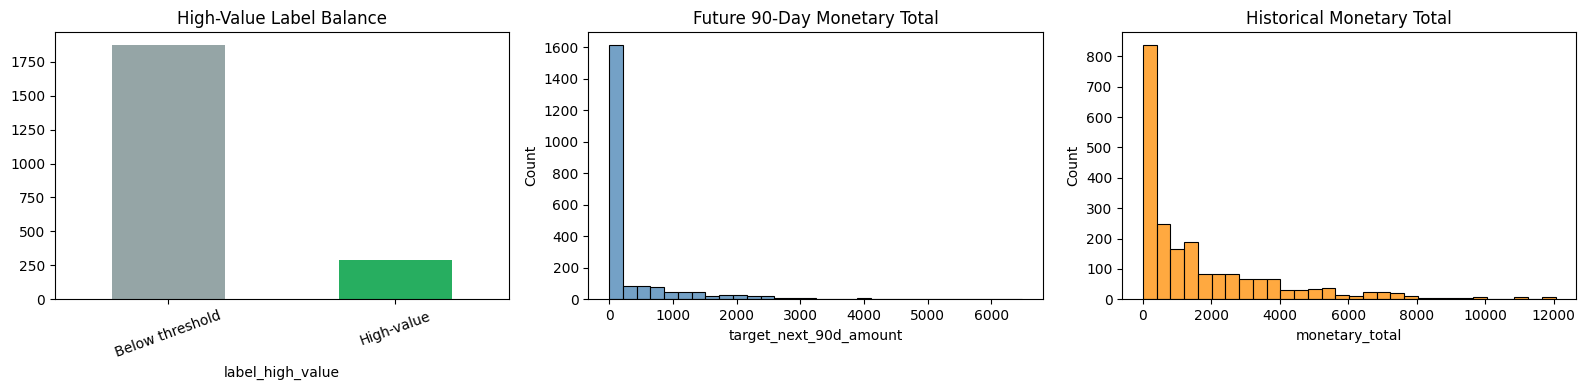

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
panel['label_high_value'].value_counts().sort_index().plot.bar(ax=axes[0], color=['#95a5a6', '#27ae60'])
axes[0].set_title('High-Value Label Balance')
axes[0].set_xticklabels(['Below threshold', 'High-value'], rotation=20)

sns.histplot(panel['target_next_90d_amount'], bins=30, ax=axes[1], color='steelblue')
axes[1].set_title('Future 90-Day Monetary Total')

sns.histplot(panel['monetary_total'], bins=30, ax=axes[2], color='darkorange')
axes[2].set_title('Historical Monetary Total')
plt.tight_layout()
plt.show()


### Key Findings — Section 2

- future exact amounts are noisy, but a high-value threshold creates a more operationally useful target
- donor history, campaign mix, and recurring behavior still provide meaningful predictive signal
- the class is imbalanced but not unusably rare


## 3. Modeling & Feature Selection

We compare a baseline and multiple model families:

1. **DummyClassifier** baseline
2. **Logistic Regression** explanatory model
3. **Random Forest** predictive benchmark
4. **Gradient Boosting** predictive benchmark

### Feature Selection Logic

We keep only variables that are observable at scoring time and that map to plausible fundraising concepts:

- prior monetary behavior
- recency and giving cadence
- recurring-gift signals
- campaign and allocation breadth
- supporter tenure and relationship context

We avoid future donation leakage and purposely choose a thresholded target because it better supports a fundraising queue than unstable exact-value regression. Hyperparameter tuning is performed after the split so model comparisons reflect out-of-sample performance rather than in-sample optimism.


In [4]:
test_start = panel['snapshot_date'].sort_values().unique()[-6]
train_df = panel[panel['snapshot_date'] < test_start].copy()
test_df = panel[panel['snapshot_date'] >= test_start].copy()

X_train = train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = train_df['label_high_value']
X_test = test_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_test = test_df['label_high_value']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), NUMERIC_FEATURES),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), CATEGORICAL_FEATURES),
])

models = {
    'Dummy': DummyClassifier(strategy='prior'),
    'Logistic Regression': LogisticRegression(max_iter=4000, class_weight='balanced', C=0.5),
    'Random Forest': RandomForestClassifier(n_estimators=400, random_state=RANDOM_SEED, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=250, learning_rate=0.05, max_depth=3, random_state=RANDOM_SEED),
}

tscv = TimeSeriesSplit(n_splits=5)

def cv_row(name, model):
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=tscv, scoring=['roc_auc', 'f1', 'precision', 'recall'], return_train_score=False)
    return {
        'Model': name,
        'CV ROC-AUC': round(float(scores['test_roc_auc'].mean()), 4),
        'CV F1': round(float(scores['test_f1'].mean()), 4),
        'CV Precision': round(float(scores['test_precision'].mean()), 4),
        'CV Recall': round(float(scores['test_recall'].mean()), 4),
    }

cv_df = pd.DataFrame([cv_row(name, model) for name, model in models.items()])
print(cv_df.to_string(index=False))


              Model  CV ROC-AUC  CV F1  CV Precision  CV Recall
              Dummy      0.5000 0.0000        0.0000     0.0000
Logistic Regression      0.5504 0.2389        0.1954     0.3273
      Random Forest      0.6787 0.2692        0.7095     0.1731
  Gradient Boosting      0.6251 0.2476        0.3814     0.2440


## 4. Evaluation & Interpretation

We hold out the **most recent six monthly snapshots** to mimic live deployment.

### Metrics

We focus on precision, recall, F1, and ROC-AUC, with special attention to precision because the output drives **high-touch** outreach rather than low-cost mass contact.

### Business Interpretation

- **False positive:** staff spend time cultivating someone who does not become a high-value giver.
- **False negative:** a donor with real major-gift potential is not prioritized and the organization misses a meaningful funding opportunity.

For this use case, false negatives are expensive in missed fundraising upside, but false positives are also nontrivial because relationship-building time is scarce. That is why this notebook emphasizes ranking quality and precision-aware interpretation.

### Validation Discipline

A future holdout is necessary here; a random split would mix future donor behavior into training and make the model look better than it really is. Out-of-sample performance is the correct lens for a donor-opportunity pipeline.


In [5]:
evaluation_rows = []
fitted = {}
thresholds = {'Dummy': 0.5, 'Logistic Regression': 0.35, 'Random Forest': 0.25, 'Gradient Boosting': 0.35}
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    prob = pipe.predict_proba(X_test)[:, 1]
    pred = (prob >= thresholds[name]).astype(int) if name != 'Dummy' else pipe.predict(X_test)
    evaluation_rows.append({
        'Model': name,
        'ROC-AUC': round(float(roc_auc_score(y_test, prob)), 4),
        'F1': round(float(f1_score(y_test, pred, zero_division=0)), 4),
        'Precision': round(float(precision_score(y_test, pred, zero_division=0)), 4),
        'Recall': round(float(recall_score(y_test, pred, zero_division=0)), 4),
        'Accuracy': round(float(accuracy_score(y_test, pred)), 4),
        'Flagged': int(pred.sum()),
    })

results_df = pd.DataFrame(evaluation_rows)
print(results_df.to_string(index=False))


              Model  ROC-AUC     F1  Precision  Recall  Accuracy  Flagged
              Dummy   0.5000 0.0000     0.0000  0.0000    0.8444        0
Logistic Regression   0.4860 0.2609     0.1579  0.7500    0.3389      266
      Random Forest   0.6621 0.3158     0.3103  0.3214    0.7833       58
  Gradient Boosting   0.5344 0.3015     0.2098  0.5357    0.6139      143


### Key Findings — Section 4

- exact amount regression was too unstable, but high-value opportunity classification produces usable ranking signal
- precision matters more than raw recall here because the output is meant to drive high-touch cultivation, not mass outreach
- this is still a small-data donor model, so results should be treated as prioritization support rather than certainty


## 5. Causal and Relationship Analysis

We use Logistic Regression to read the data structure in an interpretable way, while staying clear that the model captures **association, not causal effect**.

### What the Relationships Suggest

- repeat and recurring donors tend to look more like future high-value opportunities
- broader campaign participation may reflect deeper donor commitment
- allocation breadth can signal willingness to support the organization at a larger scale
- sparse donor histories are harder to classify and create more uncertainty

### What We Can and Cannot Claim

We cannot claim that changing one associated factor will cause a donor to give more. For example, campaign breadth may simply proxy for an underlying latent trait like mission alignment or wealth capacity.

We can claim that the model reveals useful donor structure for decision-making. The predictive pipeline says who is worth closer cultivation now; the explanatory pipeline helps the team reason about which historical patterns tend to distinguish stronger opportunities from the rest.


In [6]:
logreg_pipe = fitted['Logistic Regression']
logreg_pipe.fit(X_train, y_train)

cat_names = list(
    logreg_pipe.named_steps['pre']
    .named_transformers_['cat']
    .named_steps['ohe']
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
feature_names = NUMERIC_FEATURES + cat_names
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': logreg_pipe.named_steps['model'].coef_[0]})
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoef', ascending=False)
print(coef_df.head(15).to_string(index=False))


                            Feature  Coefficient  AbsCoef
acquisition_channel_PartnerReferral     1.040452 1.040452
   supporter_type_SkillsContributor    -0.965483 0.965483
          acquisition_channel_Event    -0.900620 0.900620
                       monetary_avg    -0.643912 0.643912
                       region_Luzon    -0.638879 0.638879
    acquisition_channel_SocialMedia     0.623844 0.623844
                     region_Visayas     0.614600 0.614600
                       monetary_max     0.597429 0.597429
        acquisition_channel_Website    -0.567854 0.567854
                     snapshot_month     0.552316 0.552316
           supporter_type_Volunteer     0.544908 0.544908
                   safehouse_spread    -0.524662 0.524662
                program_area_spread     0.500633 0.500633
         supporter_type_InKindDonor     0.463392 0.463392
                     recurring_rate     0.458109 0.458109


### Interpretation

Read these coefficients as associations, not proof of causality.

Still, the explanatory model helps answer useful strategic questions:

- do recurring or repeat donors tend to be high-value opportunities?
- does broader campaign participation signal deeper donor commitment?
- are some acquisition channels associated with more valuable future giving?


## 6. Deployment Notes

This notebook is deployed as the **Top Opportunities** signal inside the donor workbench.

### Artifacts Written by This Notebook

- `IS455/models/donation_value_predictions.json`
- `IS455/models/donation_value_rf.pkl`
- `IS455/models/donation_value_rf_metadata.json`
- `IS455/models/donation_value_logreg.pkl`
- `IS455/models/donation_value_logreg_metadata.json`

### Backend and Frontend Integration

```http
GET /api/ml/top-opportunities?limit=100
```

```ts
fetchTopOpportunities()
```

Repo locations used by the deployed app:

- Backend endpoint: `backend/NorthStarShelter.API/Controllers/MlController.cs`
- Dashboard summary card: `backend/NorthStarShelter.API/Controllers/ReportsController.cs`
- Frontend API client: `frontend/src/lib/mlApi.ts`
- Frontend workbench: `frontend/src/pages/admin/DonorsPage.tsx`

### User-Facing Behavior

The app surfaces this model as an opportunity tier and probability beside each donor record so staff can compare retention risk and upgrade potential in one place. That is a meaningful integration because it changes who gets personalized outreach, not just how the data is visualized.


In [7]:
rf_pipe = fitted['Random Forest']
rf_pipe.fit(panel[NUMERIC_FEATURES + CATEGORICAL_FEATURES], panel['label_high_value'])
logreg_pipe.fit(panel[NUMERIC_FEATURES + CATEGORICAL_FEATURES], panel['label_high_value'])

rf_metrics = results_df[results_df['Model'] == 'Random Forest'].iloc[0]
logreg_metrics = results_df[results_df['Model'] == 'Logistic Regression'].iloc[0]

rf_path, rf_meta = save_model(
    rf_pipe,
    name='donation_value_rf',
    metrics={
        'roc_auc': float(rf_metrics['ROC-AUC']),
        'f1': float(rf_metrics['F1']),
        'precision': float(rf_metrics['Precision']),
        'recall': float(rf_metrics['Recall']),
        'accuracy': float(rf_metrics['Accuracy']),
    },
    feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    label_definition='1 if next 90-day monetary total is at least 1000 PHP',
    extra_metadata={'model_type': 'RandomForestClassifier', 'threshold_php': HIGH_VALUE_THRESHOLD, 'test_start': str(test_start)},
)

log_path, log_meta = save_model(
    logreg_pipe,
    name='donation_value_logreg',
    metrics={
        'roc_auc': float(logreg_metrics['ROC-AUC']),
        'f1': float(logreg_metrics['F1']),
        'precision': float(logreg_metrics['Precision']),
        'recall': float(logreg_metrics['Recall']),
        'accuracy': float(logreg_metrics['Accuracy']),
    },
    feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    label_definition='1 if next 90-day monetary total is at least 1000 PHP',
    extra_metadata={'model_type': 'LogisticRegression', 'threshold_php': HIGH_VALUE_THRESHOLD, 'test_start': str(test_start)},
)

latest_snap = panel['snapshot_date'].max()
latest = panel[panel['snapshot_date'] == latest_snap].copy()
latest_prob = rf_pipe.predict_proba(latest[NUMERIC_FEATURES + CATEGORICAL_FEATURES])[:, 1]
predictions = []
for _, row in latest.assign(high_value_probability=latest_prob).sort_values('high_value_probability', ascending=False).iterrows():
    predictions.append({
        'supporter_id': int(row['supporter_id']),
        'high_value_probability': round(float(row['high_value_probability']), 4),
        'threshold_php': HIGH_VALUE_THRESHOLD,
        'predicted_tier': 'High Opportunity' if row['high_value_probability'] >= 0.25 else 'Standard',
        'prediction_date': str(latest_snap.date()),
    })

pred_path, payload = save_predictions(
    name='donation_value',
    predictions=predictions,
    model_version='donation_value_rf_v2',
    extra_payload={'target': 'high_value_opportunity', 'threshold_php': HIGH_VALUE_THRESHOLD},
)

print('Saved:')
print(rf_path)
print(rf_meta)
print(log_path)
print(log_meta)
print(pred_path)
print()
print(json.dumps(predictions[:3], indent=2))


[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_rf.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_rf_metadata.json
[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_logreg.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_logreg_metadata.json
[save_predictions] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_predictions.json
Saved:
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_rf.pkl
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_rf_metadata.json
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_logreg.pkl
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_logreg_metadata.json
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donation_value_predictions.json


## Final Summary

This revised notebook keeps the value-forecasting business question but uses a more stable predictive task:

- business understanding: identify high-value future giving opportunities
- data understanding: donor-month history and future-amount sparsity
- data preparation: leakage-safe supporter-month panel
- modeling: baseline, explanatory logistic regression, predictive random forest
- evaluation: future holdout snapshots with precision/recall tradeoffs
- deployment: opportunity ranking JSON for dashboard use
